# Problem 2 Judge-Facing Split Notebook

이 notebook은 Problem 2의 최종 풀이를 제시한다. fixed Hamiltonian \(H\), projected ensemble construction, random-unitary baseline과의 qualitative comparison, resource/control-cost proxy를 포함한다. 실행 재현은 `../source_code/README_FOR_JUDGES.md`를 따른다.

## Final Problem 2 Summary

- **Problem 2(a):** define the fixed three-qubit Hamiltonian on data qubits `M` plus complement qubit `F`, with \(h_x=0.8090\), \(h_y=0.9045\), and \(J=1.0\).
- **Problem 2(b):** evolve `M+F` under the fixed Hamiltonian and project/read out the complement qubit to obtain the data-system ensemble \(S_t^{\mathrm{Ham}}\).
- **Problem 2(c):** compare Hamiltonian projected diffusion qualitatively against random-unitary diffusion using the same \(D_{\mathrm{MMD}}\) and \(W_{1-F}\) metrics. The trajectory can fluctuate or partially saturate rather than monotonically approach the random-unitary Haar-like plateau.
- **Problem 2(d):** compare resource/control proxies: random layer count and entanglers versus fixed-Hamiltonian evolution time and projection/readout control.

The fixed-\(H\) baseline is made visible in `figures/fig_p2_fixed_h_baseline_visible.png` and the metric-aligned comparison is `figures/fig_metric_aligned_comparison_readable.png`. Measurement-basis variation is treated as the controlled modification in Problem 3(b), not as the main Problem 2 baseline.


In [ ]:
!pip install -q qiskit qiskit-aer scipy numpy matplotlib

import numpy as np
import scipy.linalg as la
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.circuit.library import RXGate, RYGate, RZGate, CXGate

print('Libraries loaded for this standalone problem notebook.')


In [ ]:
def generate_initial_ensemble(num_samples: int = 80, sigma: float = 0.10) -> list[Statevector]:
    """
    |00> 상태를 중심으로 미세한 각도 변위를 가진 양자 상태 앙상블을 생성합니다.

    Args:
        num_samples (int): 앙상블 크기 N (문제 조건: 50~100)
        sigma (float): 회전 각도를 추출할 정규분포의 표준편차
    Returns:
        list[Statevector]: 생성된 Statevector 객체들의 리스트
    """
    np.random.seed(2026)

    ensemble = []

    for _ in range(num_samples):
        qc = QuantumCircuit(2)

        for q in range(2):
            delta_y = np.random.normal(0, sigma)
            delta_z = np.random.normal(0, sigma)

            qc.ry(delta_y, q)
            qc.rz(delta_z, q)

        ensemble.append(Statevector(qc))

    return ensemble

N_SAMPLES = 80
SIGMA_VAL = 0.10

S_0 = generate_initial_ensemble(num_samples=N_SAMPLES, sigma=SIGMA_VAL)

print(f"✔ 앙상블 S_0 생성 완료 (총 {len(S_0)}개의 2-큐빗 상태벡터)")
print(f"  - 예시 상태벡터 0번의 기준 충실도 <00|psi_0> : {np.abs(S_0[0].data[0])**2:.4f}")


In [ ]:
def compute_pairwise_fidelity_matrix(ens1: list[Statevector], ens2: list[Statevector]) -> np.ndarray:
    """Compute pairwise fidelity F(psi, phi) = |<psi|phi>|^2 for two ensembles."""
    N1, N2 = len(ens1), len(ens2)
    F_matrix = np.zeros((N1, N2))
    for i in range(N1):
        for j in range(N2):
            F_matrix[i, j] = state_fidelity(ens1[i], ens2[j])
    return F_matrix

def compute_mmd_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    Fidelity 커널 K(psi, phi) = |<psi|phi>|^2 을 이용한 MMD^2 거리를 계산합니다.
    MMD^2 = E[K(A,A)] - 2E[K(A,B)] + E[K(B,B)]
    """
    K_AA = compute_pairwise_fidelity_matrix(ens_A, ens_A)
    K_BB = compute_pairwise_fidelity_matrix(ens_B, ens_B)
    K_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)

    mmd_sq = np.mean(K_AA) - 2 * np.mean(K_AB) + np.mean(K_BB)
    return float(np.maximum(mmd_sq, 0.0))

def compute_wasserstein_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    비충실도 Cost(psi, phi) = 1 - Fidelity 를 비용 함수로 사용하는 최적 운송(Optimal Transport) 거리를 계산합니다.
    (두 앙상블의 크기가 같으므로 헝가리안 알고리즘을 통해 일대일 매칭 최소 비용 연산)
    """
    F_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)
    cost_matrix = 1.0 - F_AB

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    total_cost = cost_matrix[row_ind, col_ind].sum()

    return float(total_cost / len(ens_A))

print("✔ MMD 거리 및 Wasserstein 거리 연산 엔진이 정의되었습니다.")


In [ ]:
def apply_random_unitary_layer(state: Statevector) -> Statevector:
    """One scrambling step: random single-qubit rotations plus one CX entangler."""
    qc = QuantumCircuit(2)
    qc.initialize(state.data, [0, 1])

    for q in range(2):
        qc.u(np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), q)

    qc.cx(0, 1)
    return Statevector(qc)

STEPS_RU = 20
S_k_history = [S_0]

np.random.seed(42)
current_ensemble = S_0
for step in range(1, STEPS_RU + 1):
    next_ensemble = [apply_random_unitary_layer(psi) for psi in current_ensemble]
    S_k_history.append(next_ensemble)
    current_ensemble = next_ensemble

mmd_list_ru = [compute_mmd_distance(S_0, S_k) for S_k in S_k_history]
wass_list_ru = [compute_wasserstein_distance(S_0, S_k) for S_k in S_k_history]
print('Shared random-unitary trajectory prepared for downstream comparisons.')


## Problem 2. Hamiltonian Projected Diffusion

문제 2에서는 data system `M`에 complement qubit `F`를 붙이고, 주어진 fixed Hamiltonian으로 시간 진화시킨 뒤 projected ensemble을 만든다. 이 방식은 매 step random gate를 샘플링하는 문제 1과 달리, 시간 독립 Hamiltonian과 projection을 이용한 diffusion model이다.


### Canonical Problem 2 baseline note

The final source-code baseline for Problem 2 uses the fixed Hamiltonian with \(h_x=0.8090\), \(h_y=0.9045\), \(J=1.0\), evolves the data-plus-complement system \(M+F\), and projects the complement qubit using a fixed reported readout basis for the baseline trajectory \(S_t^{\mathrm{Ham}}\). Any exploratory random complement-basis projection in this split notebook is retained only as legacy visualization code. The controlled measurement-basis variation is the Problem 3(b) modification, not the main Problem 2 baseline.

For inspection, the canonical implementation is in `../source_code/src/quantum_cylinder/problem_2_hamiltonian_projected_diffusion.py`.


In [5]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)

def tensor_3(A, B, C):
    """3개의 2x2 행렬 텐서곱 (시스템 순서: Q0, Q1, Q2)"""
    return np.kron(np.kron(A, B), C)

h_x, h_y, J = 0.8090, 0.9045, 1.0

H = np.zeros((8, 8), dtype=complex)

H += h_x * tensor_3(X, I, I) + h_y * tensor_3(Y, I, I)
H += h_x * tensor_3(I, X, I) + h_y * tensor_3(I, Y, I)
H += h_x * tensor_3(I, I, X) + h_y * tensor_3(I, I, Y)

H += J * tensor_3(X, X, I)
H += J * tensor_3(I, X, X)

def get_hamiltonian_evolution_operator(t: float) -> np.ndarray:
    """주어진 시간 t에 대한 유니터리 행렬 U(t) = exp(-iHt) 계산"""
    return la.expm(-1j * H * t)

print("✔ 8x8 크기의 복합 해밀토니안(M+F) 행렬 구축 완료.")
print("  - 해밀토니안 에르미트성(Hermiticity) 검증:", np.allclose(H, H.conj().T))


✔ 8x8 크기의 복합 해밀토니안(M+F) 행렬 구축 완료.
  - 해밀토니안 에르미트성(Hermiticity) 검증: True


In [6]:
def generate_projected_ensemble(initial_M_ens: list[Statevector], t: float, num_projections: int = 80) -> list[Statevector]:
    """
    해밀토니안 시간 발전 후 보조 큐빗 F를 사영 측정하여 M 상의 유효 앙상블 S_t^Ham 을 생성합니다.
    """
    U_t = get_hamiltonian_evolution_operator(t)
    projected_ens = []

    for psi_M in initial_M_ens:
        psi_3 = np.kron(psi_M.data, np.array([1, 0], dtype=complex))
        evolved_psi = U_t @ psi_3

        vec_F = Statevector(QuantumCircuit(1).compose(RXGate(np.random.uniform(0, 2*np.pi)), [0])).data

        unnorm_M = np.zeros(4, dtype=complex)
        for idx_M in range(4):
            for idx_F in range(2):
                unnorm_M[idx_M] += evolved_psi[idx_M * 2 + idx_F] * np.conj(vec_F[idx_F])

        norm = la.norm(unnorm_M)
        if norm > 1e-9:
            projected_ens.append(Statevector(unnorm_M / norm))

    return projected_ens[:num_projections]

time_list = np.linspace(0, 15, 25)
S_t_ham_history = [S_0] + [generate_projected_ensemble(S_0, t) for t in time_list[1:]]

print(f"✔ 총 {len(time_list)}개의 시간 궤적에 대해 해밀토니안 사영 앙상블 도출 완료.")


✔ 총 25개의 시간 궤적에 대해 해밀토니안 사영 앙상블 도출 완료.

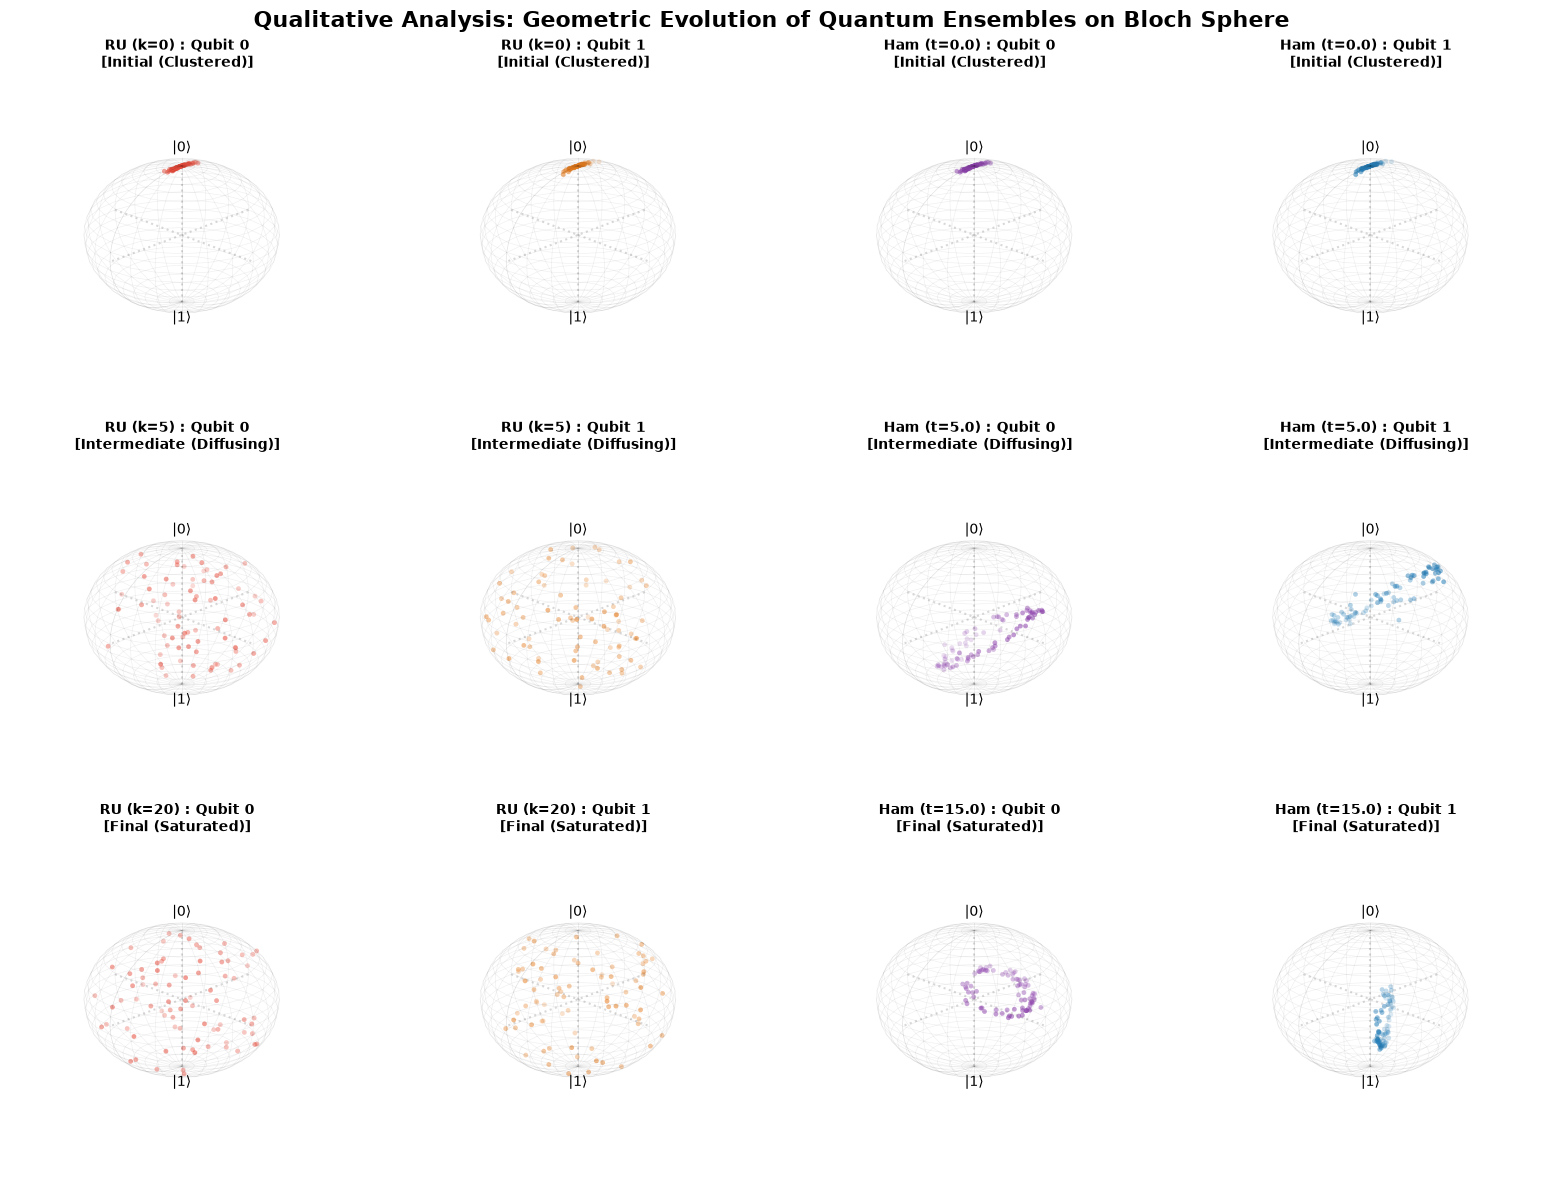

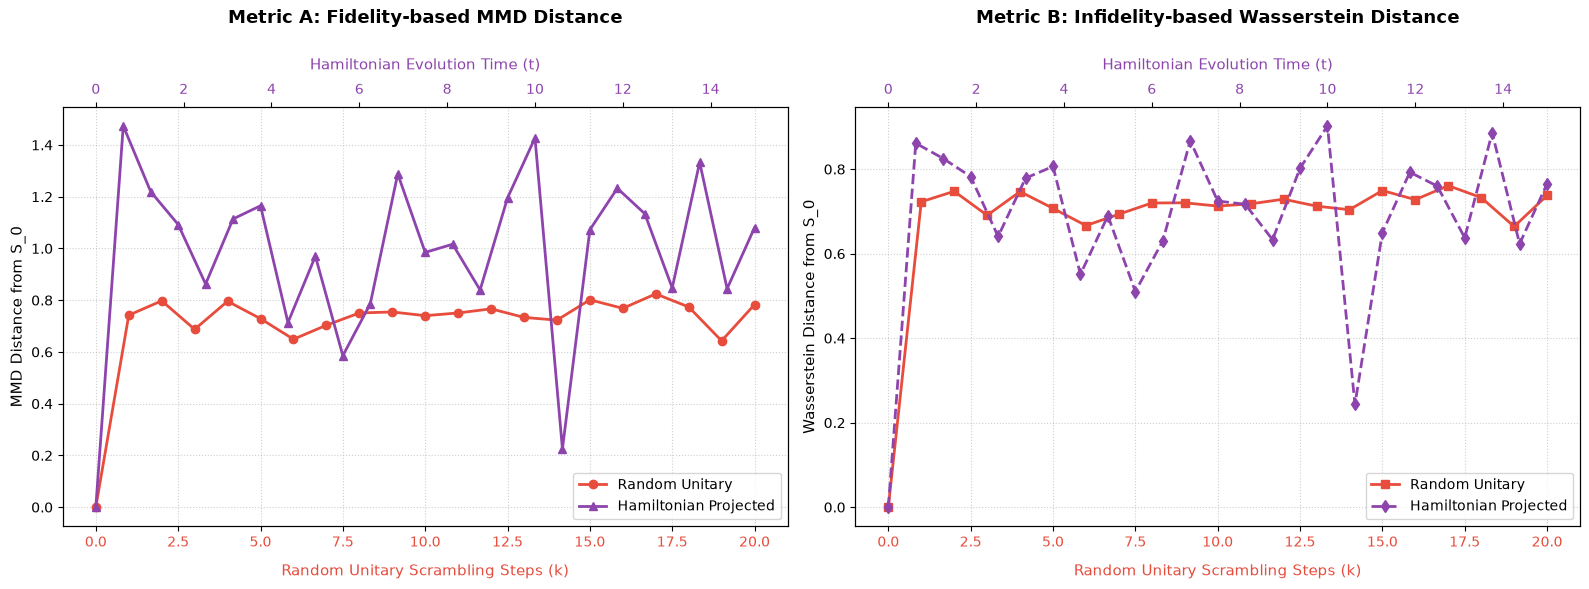

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Pauli

def get_bloch_coordinates(ensemble):
    """
    앙상블 내 각 상태를 부분 추적(Partial Trace)하여
    Qubit 0과 Qubit 1의 블로흐 벡터 (X, Y, Z 기댓값) 배열을 각각 계산합니다.
    """
    q0_points = []
    q1_points = []

    op_x0, op_y0, op_z0 = Pauli('IX'), Pauli('IY'), Pauli('IZ')
    op_x1, op_y1, op_z1 = Pauli('XI'), Pauli('YI'), Pauli('ZI')

    for psi in ensemble:
        x0 = np.real(psi.expectation_value(op_x0))
        y0 = np.real(psi.expectation_value(op_y0))
        z0 = np.real(psi.expectation_value(op_z0))
        q0_points.append([x0, y0, z0])

        x1 = np.real(psi.expectation_value(op_x1))
        y1 = np.real(psi.expectation_value(op_y1))
        z1 = np.real(psi.expectation_value(op_z1))
        q1_points.append([x1, y1, z1])

    return np.array(q0_points), np.array(q1_points)

def draw_beautiful_bloch(ax, points, title, point_color):
    """Matplotlib 3D 축 위에 정밀한 와이어프레임 블로흐 구면과 상태 점군을 스캐터링합니다."""
    u = np.linspace(0, 2 * np.pi, 25)
    v = np.linspace(0, np.pi, 25)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_wireframe(x, y, z, color='black', alpha=0.06, linewidth=0.5)

    ax.plot([-1, 1], [0, 0], [0, 0], color='gray', alpha=0.3, linestyle=':')
    ax.plot([0, 0], [-1, 1], [0, 0], color='gray', alpha=0.3, linestyle=':')
    ax.plot([0, 0], [0, 0], [-1, 1], color='gray', alpha=0.3, linestyle=':')

    ax.text(0, 0, 1.25, r'$|0\rangle$', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(0, 0, -1.25, r'$|1\rangle$', ha='center', va='center', fontsize=10, fontweight='bold')

    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color=point_color, s=12, alpha=0.75, edgecolors='none')

    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.view_init(elev=22, azim=45)
    ax.set_title(title, fontsize=10, pad=4, fontweight='bold')
    ax.axis('off')

fig_bloch = plt.figure(figsize=(16, 12))
fig_bloch.suptitle("Qualitative Analysis: Geometric Evolution of Quantum Ensembles on Bloch Sphere", \
                   fontsize=16, fontweight='bold', y=0.98)

ru_indices = [0, 5, 20]
ham_indices = [0, 8, 24]

stages = ["Initial (Clustered)", "Intermediate (Diffusing)", "Final (Saturated)"]

for row_idx in range(3):
    ru_ens = S_k_history[ru_indices[row_idx]]
    ru_q0, ru_q1 = get_bloch_coordinates(ru_ens)
    k_val = ru_indices[row_idx]

    ham_ens = S_t_ham_history[ham_indices[row_idx]]
    ham_q0, ham_q1 = get_bloch_coordinates(ham_ens)
    t_val = time_list[ham_indices[row_idx]]

    ax1 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 1, projection='3d')
    draw_beautiful_bloch(ax1, ru_q0, f"RU (k={k_val}) : Qubit 0\n[{stages[row_idx]}]", '#e74c3c')

    ax2 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 2, projection='3d')
    draw_beautiful_bloch(ax2, ru_q1, f"RU (k={k_val}) : Qubit 1\n[{stages[row_idx]}]", '#e67e22')

    ax3 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 3, projection='3d')
    draw_beautiful_bloch(ax3, ham_q0, f"Ham (t={t_val:.1f}) : Qubit 0\n[{stages[row_idx]}]", '#8e44ad')

    ax4 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 4, projection='3d')
    draw_beautiful_bloch(ax4, ham_q1, f"Ham (t={t_val:.1f}) : Qubit 1\n[{stages[row_idx]}]", '#2980b9')

plt.tight_layout()
plt.show()

mmd_ham = [compute_mmd_distance(S_0, ens) for ens in S_t_ham_history]
wass_ham = [compute_wasserstein_distance(S_0, ens) for ens in S_t_ham_history]

fig_metrics, (ax_mmd1, ax_wass1) = plt.subplots(1, 2, figsize=(16, 6))

color_ru = '#e74c3c'
color_ham = '#8e44ad'

ax_mmd1.set_xlabel('Random Unitary Scrambling Steps (k)', color=color_ru, fontsize=11, labelpad=10)
ax_mmd1.set_ylabel('MMD Distance from S_0', fontsize=11)
line_mmd1 = ax_mmd1.plot(range(STEPS_RU + 1), mmd_list_ru, 'o-', color=color_ru, label='Random Unitary', lw=2)
ax_mmd1.tick_params(axis='x', labelcolor=color_ru)

ax_mmd2 = ax_mmd1.twiny()
ax_mmd2.set_xlabel('Hamiltonian Evolution Time (t)', color=color_ham, fontsize=11, labelpad=10)
line_mmd2 = ax_mmd2.plot(time_list, mmd_ham, '^-', color=color_ham, label='Hamiltonian Projected', lw=2)
ax_mmd2.tick_params(axis='x', labelcolor=color_ham)

lines_mmd = line_mmd1 + line_mmd2
labels_mmd = [l.get_label() for l in lines_mmd]
ax_mmd1.legend(lines_mmd, labels_mmd, loc='lower right', fontsize=10, frameon=True)
ax_mmd1.set_title("Metric A: Fidelity-based MMD Distance", fontsize=13, fontweight='bold', pad=25)
ax_mmd1.grid(True, linestyle=':', alpha=0.6)

ax_wass1.set_xlabel('Random Unitary Scrambling Steps (k)', color=color_ru, fontsize=11, labelpad=10)
ax_wass1.set_ylabel('Wasserstein Distance from S_0', fontsize=11)
line_wass1 = ax_wass1.plot(range(STEPS_RU + 1), wass_list_ru, 's-', color=color_ru, label='Random Unitary', lw=2)
ax_wass1.tick_params(axis='x', labelcolor=color_ru)

ax_wass2 = ax_wass1.twiny()
ax_wass2.set_xlabel('Hamiltonian Evolution Time (t)', color=color_ham, fontsize=11, labelpad=10)
line_wass2 = ax_wass2.plot(time_list, wass_ham, 'd--', color=color_ham, label='Hamiltonian Projected', lw=2)
ax_wass2.tick_params(axis='x', labelcolor=color_ham)

lines_wass = line_wass1 + line_wass2
labels_wass = [l.get_label() for l in lines_wass]
ax_wass1.legend(lines_wass, labels_wass, loc='lower right', fontsize=10, frameon=True)
ax_wass1.set_title("Metric B: Infidelity-based Wasserstein Distance", fontsize=13, fontweight='bold', pad=25)
ax_wass1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### 해설

시각화는 random-unitary와 Hamiltonian projected diffusion의 초기, 중간, 후반 상태를 비교한다.


Metric-aligned comparable points
- by MMD:
  random step k=20, MMD=0.783188
  Hamiltonian time t=6.250000, MMD=0.786496
  absolute gap=0.003308
- by Wasserstein:
  random step k=11, W=0.717861
  Hamiltonian time t=8.125000, W=0.716944
  absolute gap=0.000917

Resource/control proxy at the MMD-matched point
Random Unitary Scrambling
  native_parameter: k=20
  single_qubit_U_gates_per_sample: 40
  euler_angle_controls_per_sample: 120
  CX_entanglers_per_sample: 20
  random_angle_draws_per_sample: 120
  random_angle_draws_per_ensemble: 9600
Hamiltonian Projected Diffusion
  native_parameter: t=6.250000
  fixed_pauli_terms_in_H: 8
  independent_fixed_coefficients: 3
  nonlocal_XX_terms: 2
  time_control_parameters: 1
  projection_operations_per_sample: 1
  projection_basis_angle_draws_per_sample: 1
  projection_basis_angle_draws_per_ensemble: 80


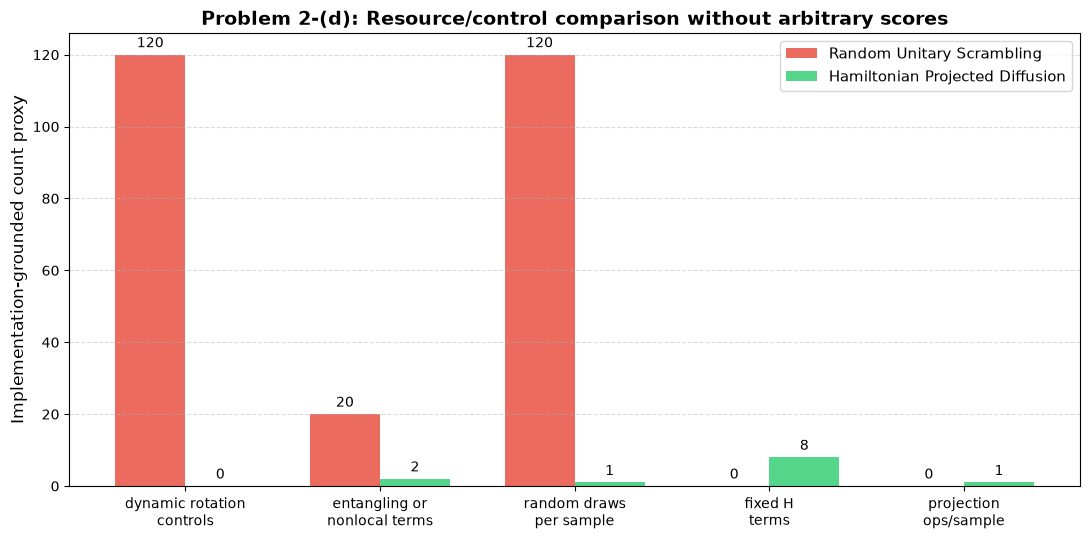


Interpretation
- The numbers above are not subjective 0~10 scores; they are count proxies derived from the implemented circuits/maps.
- Random-unitary diffusion requires new local rotation controls and a CX entangler at every step.
- Hamiltonian projected diffusion uses a fixed 8-term Hamiltonian, one continuous time parameter, and a final projection step.
- Because k and t are different native parameters, the comparison uses metric-matched points rather than equal x-axis locations.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def nearest_metric_pair(random_values, hamiltonian_values, random_parameters, hamiltonian_parameters):
    """Find a non-initial random/Hamiltonian pair with the closest metric value."""
    best = None
    for i in range(1, len(random_values)):
        for j in range(1, len(hamiltonian_values)):
            gap = abs(float(random_values[i]) - float(hamiltonian_values[j]))
            candidate = {
                'gap': gap,
                'random_index': i,
                'hamiltonian_index': j,
                'random_parameter': random_parameters[i],
                'hamiltonian_parameter': hamiltonian_parameters[j],
                'random_value': float(random_values[i]),
                'hamiltonian_value': float(hamiltonian_values[j]),
            }
            if best is None or gap < best['gap']:
                best = candidate
    return best

random_steps = np.arange(len(mmd_list_ru))
hamiltonian_times = np.asarray(time_list, dtype=float)

mmd_match = nearest_metric_pair(mmd_list_ru, mmd_ham, random_steps, hamiltonian_times)
wass_match = nearest_metric_pair(wass_list_ru, wass_ham, random_steps, hamiltonian_times)

def random_unitary_resource_proxy(step):
    step = int(step)
    return {
        'native_parameter': f'k={step}',
        'single_qubit_U_gates_per_sample': 2 * step,
        'euler_angle_controls_per_sample': 2 * 3 * step,
        'CX_entanglers_per_sample': step,
        'random_angle_draws_per_sample': 2 * 3 * step,
        'random_angle_draws_per_ensemble': len(S_0) * 2 * 3 * step,
    }

def hamiltonian_resource_proxy(time):
    return {
        'native_parameter': f't={float(time):.6f}',
        'fixed_pauli_terms_in_H': 8,
        'independent_fixed_coefficients': 3,
        'nonlocal_XX_terms': 2,
        'time_control_parameters': 1,
        'projection_operations_per_sample': 1,
        'projection_basis_angle_draws_per_sample': 1,
        'projection_basis_angle_draws_per_ensemble': len(S_0),
    }

print('Metric-aligned comparable points')
print('- by MMD:')
print(f"  random step k={int(mmd_match['random_parameter'])}, MMD={mmd_match['random_value']:.6f}")
print(f"  Hamiltonian time t={mmd_match['hamiltonian_parameter']:.6f}, MMD={mmd_match['hamiltonian_value']:.6f}")
print(f"  absolute gap={mmd_match['gap']:.6f}")
print('- by Wasserstein:')
print(f"  random step k={int(wass_match['random_parameter'])}, W={wass_match['random_value']:.6f}")
print(f"  Hamiltonian time t={wass_match['hamiltonian_parameter']:.6f}, W={wass_match['hamiltonian_value']:.6f}")
print(f"  absolute gap={wass_match['gap']:.6f}")

selected = mmd_match
ru_proxy = random_unitary_resource_proxy(selected['random_parameter'])
ham_proxy = hamiltonian_resource_proxy(selected['hamiltonian_parameter'])

print('\nResource/control proxy at the MMD-matched point')
print('Random Unitary Scrambling')
for key, value in ru_proxy.items():
    print(f'  {key}: {value}')
print('Hamiltonian Projected Diffusion')
for key, value in ham_proxy.items():
    print(f'  {key}: {value}')

categories = [
    'dynamic rotation\ncontrols',
    'entangling or\nnonlocal terms',
    'random draws\nper sample',
    'fixed H\nterms',
    'projection\nops/sample',
]
ru_values = [
    ru_proxy['euler_angle_controls_per_sample'],
    ru_proxy['CX_entanglers_per_sample'],
    ru_proxy['random_angle_draws_per_sample'],
    0,
    0,
]
ham_values = [
    0,
    ham_proxy['nonlocal_XX_terms'],
    ham_proxy['projection_basis_angle_draws_per_sample'],
    ham_proxy['fixed_pauli_terms_in_H'],
    ham_proxy['projection_operations_per_sample'],
]

x = np.arange(len(categories))
width = 0.36
fig, ax = plt.subplots(figsize=(11, 5.5))
rects1 = ax.bar(x - width / 2, ru_values, width, label='Random Unitary Scrambling', color='#e74c3c', alpha=0.82)
rects2 = ax.bar(x + width / 2, ham_values, width, label='Hamiltonian Projected Diffusion', color='#2ecc71', alpha=0.82)

ax.set_ylabel('Implementation-grounded count proxy', fontsize=12)
ax.set_title('Problem 2-(d): Resource/control comparison without arbitrary scores', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.45)
ax.bar_label(rects1, padding=3, fmt='%d')
ax.bar_label(rects2, padding=3, fmt='%d')
plt.tight_layout()
plt.show()

print('\nInterpretation')
print('- The numbers above are not subjective 0~10 scores; they are count proxies derived from the implemented circuits/maps.')
print('- Random-unitary diffusion requires new local rotation controls and a CX entangler at every step.')
print('- Hamiltonian projected diffusion uses a fixed 8-term Hamiltonian, one continuous time parameter, and a final projection step.')
print('- Because k and t are different native parameters, the comparison uses metric-matched points rather than equal x-axis locations.')


### Problem 2 결과 해석

Hamiltonian projected diffusion은 random-unitary diffusion과 같은 x축 단위를 공유하지 않는다. 따라서 두 방식은 동일 시간의 수치 비교보다, target ensemble에서 멀어지는 거리 곡선의 양상과 control/resource proxy를 함께 비교하는 것이 타당하다. Fixed Hamiltonian 방식은 제어해야 하는 gate parameter 수를 줄이는 장점이 있고, projection과 evolution time 선택이 주요 trade-off가 된다.
